In [1]:
%pip install scikit-learn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load processed data
df = pd.read_csv("../data/processed/world_bank_clean.csv")
print("Machine learning libraries initialized and data loaded successfully!")

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 12.1 MB 3.5 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 43.7 MB/s eta 0:00:01
     |████████████████████████████████| 39.4 MB 31 kB/s s eta 0:00:01    |█████▉                          | 7.2 MB 32.8 MB/s eta 0:00:01     |███████████████████████████████▍| 38.6 MB 52.0 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Machine learning libraries initialized and data loaded successfully!


In [2]:
# Define features (X) and target (y)
features = [
    "inflation", "unemployment", "govt_debt_pct_gdp", 
    "trade_pct_gdp", "gdp_per_capita", "high_inflation",
    "gdp_growth_lag1", "gdp_growth_lag2"
]

# Drop any remaining row that has a missing value in these specific columns
df_ml = df.dropna(subset=features + ["gdp_growth"])

X = df_ml[features]
y = df_ml["gdp_growth"]

# Split into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (1324, 8)
Testing features shape: (331, 8)


In [3]:

lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)


lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)


lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)


print("--- LINEAR REGRESSION PERFORMANCE ---")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, lr_preds):.4f}")
print(f"R2 Score: {r2_score(y_test, lr_preds):.4f}\n")

print("--- RANDOM FOREST PERFORMANCE ---")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, rf_preds):.4f}")
print(f"R2 Score: {r2_score(y_test, rf_preds):.4f}")

--- LINEAR REGRESSION PERFORMANCE ---
Mean Squared Error (MSE): 15.2542
R2 Score: 0.0197

--- RANDOM FOREST PERFORMANCE ---
Mean Squared Error (MSE): 15.5738
R2 Score: -0.0008


/var/folders/d7/6xbrn4v15d149hyfn6m1gtym0000gn/T/ipykernel_27880/4141913825.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")


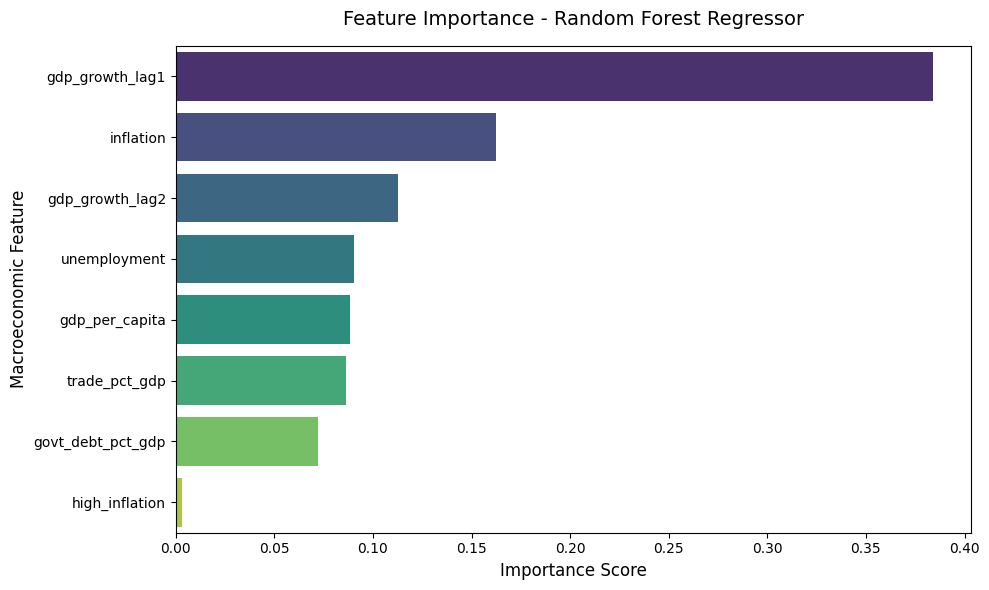

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [features[i] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")
plt.title("Feature Importance - Random Forest Regressor", fontsize=14, pad=15)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Macroeconomic Feature", fontsize=12)
plt.tight_layout()
plt.show()